In [1]:
import time
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,GradientBoostingClassifier,VotingClassifier,IsolationForest,ExtraTreesClassifier)
from sklearn.metrics import (accuracy_score,classification_report)

# <center> Feature Engineering and Feature Importance

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("train_test_network.csv")
print(df.shape)
df.head()

(211043, 44)


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [3]:
df=df.sample(30000,random_state=42)

## Drop High Cardinality Leakage Features:

In [4]:
drop_cols=["src_ip","dst_ip","dns_query","ssl_subject","ssl_issuer","http_uri","http_user_agent"]
df=df.drop(
columns=[
c for c in drop_cols
if c in df.columns
]
)

## Feature Engineering:

In [5]:
# Ratios
df["byte_ratio"]=(df["src_bytes"]/(df["dst_bytes"]+1))
df["packet_ratio"]=(df["src_pkts"]/(df["dst_pkts"]+1))

# Traffic intensity
df["pkts_per_sec"]=(df["src_pkts"]+df["dst_pkts"])/(df["duration"]+1)
df["bytes_per_sec"]=(df["src_bytes"]+df["dst_bytes"])/(df["duration"]+1)

# Totals
df["total_bytes"]=(df["src_bytes"]+df["dst_bytes"])
df["total_pkts"]=(df["src_pkts"]+df["dst_pkts"])

In [6]:
df.head()

,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,weird_addl,weird_notice,label,type,byte_ratio,packet_ratio,pkts_per_sec,bytes_per_sec,total_bytes,total_pkts
149315,40172,80,tcp,http,0.011460,155,978,SF,0,5,...,-,-,1,password,0.158325,1.000000,8.898029,1120.162933,1133,9
66176,44000,80,tcp,http,1.247144,251,12183,SF,0,6,...,-,-,1,injection,0.020601,0.428571,8.455177,5533.245756,12434,19
18650,50068,80,tcp,-,0.000104,0,0,REJ,0,1,...,-,-,1,backdoor,0.000000,0.500000,1.999792,0.000000,0,2
199593,52620,80,tcp,-,0.000000,0,0,SH,0,1,...,-,-,1,xss,0.000000,1.000000,1.000000,0.000000,0,1
60358,41786,80,tcp,http,0.965070,234,12183,SF,0,6,...,-,-,1,injection,0.019206,0.461538,9.159979,6318.858870,12417,18


## Features and Target:

In [7]:
X=df.drop(["label","type"],axis=1)
y=df["label"]

## One Hot Encode Better):

In [8]:
X=pd.get_dummies(X,drop_first=True)

In [9]:
print(X.shape)

(30000, 87)


# <center> Models

## Split:

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

## Scaling:

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## Decision Tree:

In [12]:
dt=DecisionTreeClassifier(random_state=42)
start=time.time()
dt.fit(X_train,y_train)
print("Decision Tree Train Time:",time.time()-start)
start=time.time()
pred=dt.predict(X_test)
print("Prediction Time:",time.time()-start)
print("Accuracy:",accuracy_score(y_test,pred))

Decision Tree Train Time: 0.2772953510284424
Prediction Time: 0.0
Accuracy: 0.9964444444444445


## Random Forest:

In [13]:
rf=RandomForestClassifier(n_estimators=100)
start=time.time()
rf.fit(X_train,y_train)
print("RF Train Time:",time.time()-start)
start=time.time()
pred=rf.predict(X_test)
print("RF Prediction Time:",time.time()-start)
print("Accuracy:",accuracy_score(y_test,pred))

RF Train Time: 2.364896535873413
RF Prediction Time: 0.07010221481323242
Accuracy: 0.9975555555555555


## Extra Trees:

In [14]:
et=ExtraTreesClassifier(n_estimators=100,random_state=42)
start=time.time()
et.fit(X_train,y_train)
print("ET Train Time:",time.time()-start)
start=time.time()
pred=et.predict(X_test)
print("ET Prediction Time:",time.time()-start)
print("Accuracy:",accuracy_score(y_test,pred))

ET Train Time: 1.6275482177734375
ET Prediction Time: 0.10550618171691895
Accuracy: 0.9976666666666667


## Isolation Forest:

In [15]:
X_normal=X_train[y_train==0]
iso=IsolationForest(n_estimators=200,contamination=0.30,random_state=42)
start=time.time()
iso.fit(X_normal)
print("Isolation Forest Train Time:",time.time()-start)
start=time.time()
pred=iso.predict(X_test)
pred=np.where(pred==-1,1,0)
print("Isolation Prediction Time:",time.time()-start)
print("Accuracy:",accuracy_score(y_test,pred))

Isolation Forest Train Time: 0.5168027877807617
Isolation Prediction Time: 0.11655926704406738
Accuracy: 0.4776666666666667


## XGBoost:

In [16]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=200,max_depth=8,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,random_state=42)

In [17]:
import time
start=time.time()
xgb.fit(X_train,y_train)
xgb_time=time.time()-start
print("Training Time:",xgb_time)

Training Time: 1.0753633975982666


In [18]:
start_pred = time.time()
xgb_preds = xgb.predict(X_test)
end_pred = time.time()
xgb_pred_time = end_pred - start_pred
print("XGBoost Prediction Time:", xgb_pred_time)

XGBoost Prediction Time: 0.014654874801635742


In [19]:
from sklearn.metrics import accuracy_score
pred=xgb.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9977777777777778


## Feature Importance:

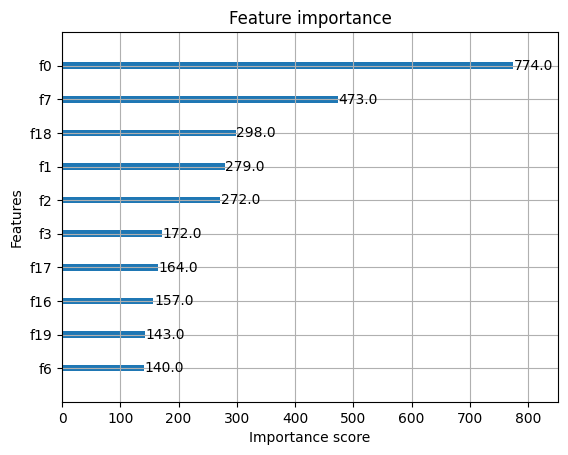

In [20]:
# Top 10 important features:
from xgboost import plot_importance
import matplotlib.pyplot as plt
plot_importance(xgb,max_num_features=10)
plt.show()

## Hybrid Model:

In [21]:
X_normal = X_train[y_train==0]
iso = IsolationForest(n_estimators=200,contamination=0.30,random_state=42)

In [22]:
start_train=time.time()
xgb.fit(X_train,y_train)
X_normal=X_train[y_train==0]
iso.fit(X_normal)
hybrid_time=time.time()-start_train
print("Training Time:",hybrid_time)

Training Time: 1.5126895904541016


In [23]:
start_pred=time.time()
probs=xgb.predict_proba(X_test)[:,1]
hybrid_preds=[]
for i,row in enumerate(X_test):
    # confident attack
    if probs[i] > 0.70:
        hybrid_preds.append(1)
    # confident normal
    elif probs[i] < 0.30:
        hybrid_preds.append(0)
    # uncertain region → consult anomaly detector
    else:
        anomaly=iso.predict(row.reshape(1,-1))[0]
        if anomaly==-1:
            hybrid_preds.append(1)
        else:
            hybrid_preds.append(0)
            
hybrid_preds=np.array(hybrid_preds)
hybrid_pred_time=time.time()-start_pred
print("Prediction Time:",hybrid_pred_time)

Prediction Time: 0.31302690505981445


In [24]:
print("Hybrid Accuracy:",accuracy_score(y_test,hybrid_preds))
print(classification_report(y_test,hybrid_preds))

Hybrid Accuracy: 0.9977777777777778
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2106
           1       1.00      1.00      1.00      6894

    accuracy                           1.00      9000
   macro avg       1.00      1.00      1.00      9000
weighted avg       1.00      1.00      1.00      9000



In [25]:
dt_acc = accuracy_score(y_test, dt.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))
et_acc = accuracy_score(y_test, et.predict(X_test))
iso_pred = iso.predict(X_test)
iso_pred = np.where(iso_pred==-1,1,0)
iso_acc = accuracy_score(y_test, iso_pred)
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
hybrid_acc = accuracy_score(y_test, hybrid_preds)

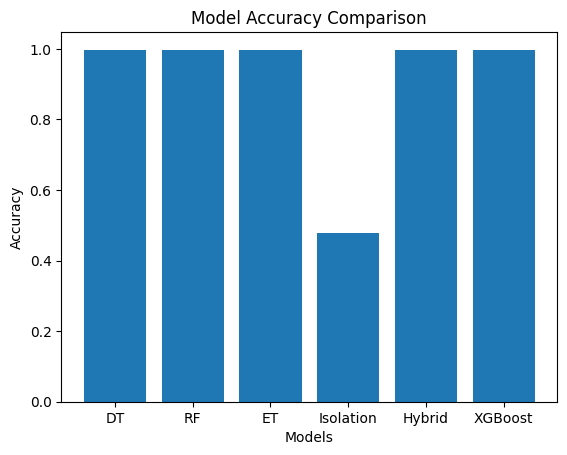

In [26]:
import matplotlib.pyplot as plt
models = ["DT","RF","ET","Isolation","Hybrid","XGBoost"]
accuracy = [dt_acc,rf_acc,et_acc,iso_acc,hybrid_acc,xgb_acc]
plt.figure()
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

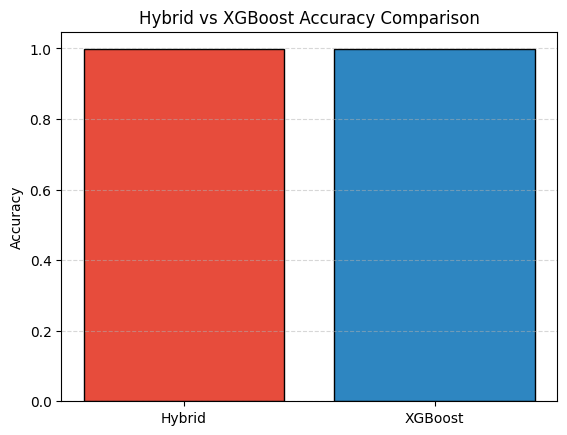

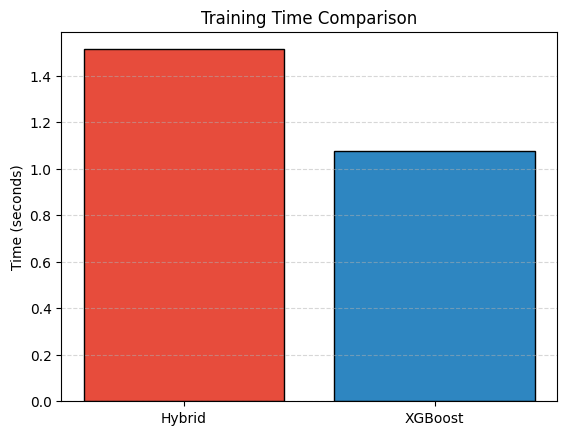

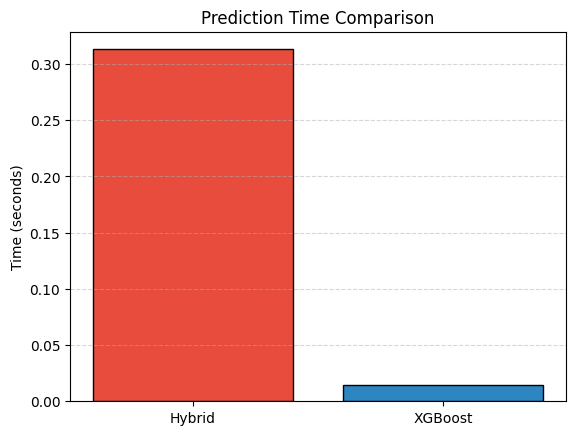

In [27]:
import matplotlib.pyplot as plt
# Models
models = ["Hybrid", "XGBoost"]
# Values
accuracy = [hybrid_acc,xgb_acc]
train_time = [hybrid_time,xgb_time]
pred_time = [hybrid_pred_time,xgb_pred_time]
# Colors (Hybrid highlighted)
colors = ["#E74C3C", "#2E86C1"]  # Red = Hybrid, Blue = XGBoost
# Accuracy Plot
plt.figure()
plt.bar(models, accuracy, color=colors, edgecolor="black")
plt.title("Hybrid vs XGBoost Accuracy Comparison")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
# Training Time Plot
plt.figure()
plt.bar(models, train_time, color=colors, edgecolor="black")
plt.title("Training Time Comparison")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
# Prediction Time Plot
plt.figure()
plt.bar(models, pred_time, color=colors, edgecolor="black")
plt.title("Prediction Time Comparison")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()